## Build your Own

## Probability Basic

In [3]:
import math
import random
from functools import reduce

def factorial(n):
    return reduce(lambda x, y: x * y, range(1, n + 1), 1)

def combinations(n, k):
    return factorial(n) // (factorial(k) * factorial(n - k))

def conditional_probability(p_a_and_b, p_b):
    return p_a_and_b / p_b


p_king_given_face = conditional_probability(4 / 52, 12 / 52)
print(f"P(King | Face card) = {p_king_given_face:.4f}")

P(King | Face card) = 0.3333


## PML and PDF

In [4]:
def bernoulli_pmf(k, p):
    return p if k == 1 else (1 - p)

def categorical_pmf(k, probs):
    return probs[k]

def poisson_pmf(k, lam):
    return (lam ** k) * math.exp(-lam) / factorial(k)

def uniform_pdf(x, a, b):
    if a <= x <= b:
        return 1.0 / (b - a)
    return 0.0

def normal_pdf(x, mu, sigma):
    coeff = 1.0 / (sigma * math.sqrt(2 * math.pi))
    exponent = -0.5 * ((x - mu) / sigma) ** 2
    return coeff * math.exp(exponent)

## Expected value and variance

In [6]:
def expected_value(values, probs):
    return sum(v * p for v, p in zip(values, probs))

def variance(values, probs):
    expected = expected_value(values, probs)
    return sum(p * (v - expected) ** 2 for v, p in zip(values, probs))

die_values = list(range(1, 6 + 1))
die_probs = [1/6] * 6

print(f"Expected value of die: {expected_value(die_values, die_probs):.2f}")
print(f"Variance of die: {variance(die_values, die_probs):.2f}")
    

Expected value of die: 3.50
Variance of die: 2.92


## Sampling for distribution

In [12]:
def sample_bernoulli(p, n = 1):
    return [1 if random.random() < p else 0 for _ in range(n)]

def sample_categorical(probs, n = 1):
    return [random.choices(range(len(probs)), weights=probs) for _ in range(n)]

def sample_normal_box_muller(mu, sigma, n= 1):
    return [mu + sigma * (
        math.sqrt(-2 * math.log(random.random())) * math.cos(2 * math.pi * random.random())
    ) for _ in range(n)]

print('*' * 50)
print('Test sample_bernoulli')
print(sample_bernoulli(0.5, 10))

print('*' * 50)
print('Test sample_categorical')
print(sample_categorical([0.1, 0.4, 0.5], 10))

print('*' * 50)
print('Test sample_normal_box_muller')
print(sample_normal_box_muller(0, 1, 10))


**************************************************
Test sample_bernoulli
[1, 1, 0, 1, 0, 0, 1, 1, 1, 1]
**************************************************
Test sample_categorical
[[1], [1], [2], [1], [1], [2], [1], [2], [1], [2]]
**************************************************
Test sample_normal_box_muller
[-0.5582883079073704, 0.31973967529398495, -1.728381640516853, 1.4444284446219338, 1.0613365707707523, -0.16300859533756284, -0.9496398078831173, 0.6213447074468018, 0.23447289965378834, -1.231273547812846]


## SoftMax

SoftMax 把一组任意实数（logits）映射成一个合法的概率分布：每一项非负，且所有项之和为 1。

基本原理。先对每个 logit 做指数：`exp(z_i)` 保证非负，同时放大较大值、压小较小值。再除以所有指数之和做归一化：

`softmax(z)_i = exp(z_i) / Σ_j exp(z_j)`

输出可直接解读为「属于第 i 类的概率」。代码里先减去 `max(logits)`，是为了避免 `exp` 溢出，结果数学上不变。`log_softmax` 则在 log 域计算同一分布，数值更稳；再取真实类别那一项的负对数，就是交叉熵损失 `cross_entropy`。

为什么在深度学习里广泛使用。多分类网络的最后一层通常输出未归一化的分数，SoftMax 把它们变成概率，便于解释和采样。它处处可微，梯度能顺利反传。与交叉熵搭配时，损失直接惩罚「真实类概率不够高」，训练信号清晰。相比硬取 argmax，SoftMax 保留各类之间的相对置信度，优化更平滑。

In [13]:
def softmax(logits):
    max_logit = max(logits)
    exp_logits = [math.exp(logit - max_logit) for logit in logits]
    total = sum(exp_logits)
    return [e / total for e in exp_logits]

def log_softmax(logits):
    max_logit = max(logits)
    exp_logits = [math.exp(logit - max_logit) for logit in logits]
    log_sum_exp = max_logit + math.log(sum(exp_logits))
    return [logit - log_sum_exp for logit in logits]

def cross_entropy(logits, target_index):
    log_probs = log_softmax(logits)
    return -log_probs[target_index]

## Central Limit Theorem Demonstration

In [14]:
def demonstrate_clt(dist_fn, n_samples, n_averages):
    averages = []
    for _ in range(n_averages):
        smaples = [dist_fn() for _ in range(n_samples)]
        averages.append(sum(smaples) / n_samples)
    return averages


## Visualization

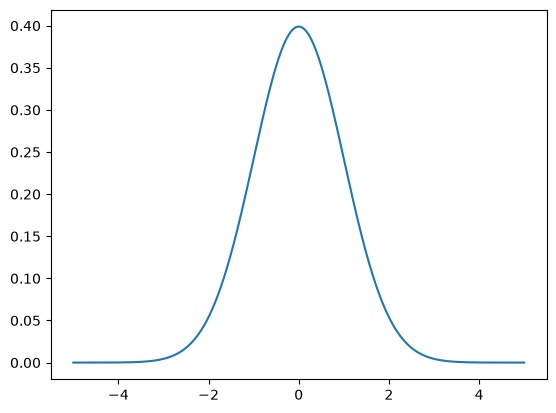

In [15]:
%matplotlib inline

import matplotlib.pyplot as plt
from networkx import sigma

mu = 0
sigma = 1

xs = [mu + sigma * (i - 500) / 100 for i in range(1001)]
ys = [normal_pdf(x, mu, sigma) for x in xs]

plt.plot(xs, ys)



## Built in functions

In [16]:
import numpy as np
from scipy import stats

normal = stats.norm(loc=0, scale=1)
samples = normal.rvs(size = 10000)

print(f"Mean: {np.mean(samples):.4f}, Std: {np.std(samples):.4f}")
print(f"P(X < 1.96) = {normal.cdf(1.96):.4f}")

logits = np.array([2.0, 1.0, 0.1])
from scipy.special import softmax, log_softmax

probs = softmax(logits)
print(f"Softmax: {probs}")

log_probs = log_softmax(logits)
print(f"Log softmax: {log_probs}")



Mean: 0.0196, Std: 1.0029
P(X < 1.96) = 0.9750
Softmax: [0.65900114 0.24243297 0.09856589]
Log softmax: [-0.41703002 -1.41703002 -2.31703002]
